In [ ]:
from pathlib import Path
from collections import Counter
import shutil
import tensorflow as tf
from tensorflow.keras import applications, layers, models, optimizers, callbacks, utils
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import seaborn as sns
import random, os

In [ ]:
# counting numbers of samples in each class

path = Path("/content/drive/MyDrive/Fabrics")

counts = {}

for fabric_folder in sorted(path.iterdir()):
    if not fabric_folder.is_dir():
        continue
    fabric_name = fabric_folder.name
    sample_count = len([p for p in fabric_folder.iterdir() if p.is_dir() and p.name.isdigit()])
    counts[fabric_name] = sample_count
    print(f"{fabric_name:20} → {sample_count:4} samples")

print("-------------------------------------")
total = sum(counts.values())
print(f"TOTAL SAMPLES       → {total}")
print(f"TOTAL CLASSES       → {len(counts)}")

Acrylic              →   12 samples
Artificial_fur       →    1 samples
Artificial_leather   →    3 samples
Blended              →  411 samples
Chenille             →   13 samples
Corduroy             →   24 samples
Cotton               →  588 samples
Crepe                →   26 samples
Denim                →  162 samples
Felt                 →    4 samples
Fleece               →   33 samples
Leather              →   16 samples
Linen                →   19 samples
Lut                  →    4 samples
Nylon                →   57 samples
Polyester            →  226 samples
Satin                →   24 samples
Silk                 →   50 samples
Suede                →    5 samples
Terrycloth           →   30 samples
Unclassified         →  123 samples
Utilities            →    0 samples
Velvet               →   11 samples
Viscose              →   37 samples
Wool                 →   90 samples
-------------------------------------
TOTAL SAMPLES       → 1969
TOTAL CLASSES       → 25


In [ ]:
dest = Path("/content/drive/MyDrive/Fabrics cleaned")
dest.mkdir(exist_ok=True)

drop_th = 10
merge_th = 40

other_folder = dest / "other"
other_folder.mkdir(exist_ok=True)

for folder in path.iterdir():
    if not folder.is_dir():
        continue

    name = folder.name
    count = counts.get(name, 0)

    if name == "Unclassified" or count < drop_th:
        continue

    elif count < merge_th:
        for item in folder.iterdir():
            if item.is_dir() and item.name.isdigit():
                shutil.copytree(item, other_folder / item.name, dirs_exist_ok=True)

    else:
        shutil.copytree(folder, dest / name, dirs_exist_ok=True)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Fabrics cleaned"
IMG_SIZE = (224, 224)
BATCH_SIZE = 12
CONFIDENCE_THRESHOLD = 0.75
SEED = 2025
EPOCHS = 30

In [ ]:
tf.keras.utils.set_random_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
data_dir = Path(DATA_PATH)
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
n_classes = len(class_names)

class_names

['Blended', 'Cotton', 'Denim', 'Nylon', 'Polyester', 'Silk', 'Wool', 'other']

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

train_ds = train_ds.shuffle(500).prefetch(2)
val_ds = val_ds.prefetch(2)

Found 7293 files belonging to 8 classes.
Using 5835 files for training.
Found 7293 files belonging to 8 classes.
Using 1458 files for validation.


In [ ]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),
])

In [ ]:
from pathlib import Path

data_dir = Path(DATA_PATH)
class_counts = {}

for class_folder in data_dir.iterdir():
    if class_folder.is_dir():
        count = len([p for p in class_folder.iterdir() if p.is_dir() and p.name.isdigit()])
        class_counts[class_folder.name] = count

total = sum(class_counts.values())
n_classes = len(class_counts)
class_weights = {i: total / (n_classes * count) for i, (cls, count) in enumerate(class_counts.items())}

print("\nClass weights")
for i, cls in enumerate(class_names):
    print(f"  {cls:15} → {class_weights[i]:.3f}")


Class weights
  Blended         → 4.558
  Cotton          → 3.998
  Denim           → 1.407
  Nylon           → 1.008
  Polyester       → 0.953
  Silk            → 2.532
  Wool            → 0.388
  other           → 0.554


In [ ]:
base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base.trainable = True

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = layers.Rescaling(1./255)(inputs)
x = augment(x)
x = base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        16,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 23,550,984 (89.84 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = callbacks.ModelCheckpoint(
    "best_fabric_model.keras",
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

early = callbacks.EarlyStopping(patience=8, restore_best_weights=True)
reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint, early, reduce],
    verbose=1
)

model.save("final_fabric_model.keras")
print("Training finished — best model saved as .keras")

Epoch 1/25
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3527 - loss: 4.2032
Epoch 1: val_accuracy improved from -inf to 0.22222, saving model to best_fabric_model.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 2982s 1s/step - accuracy: 0.3528 - loss: 4.2014 - val_accuracy: 0.2222 - val_loss: 7.6625 - learning_rate: 3.0000e-05
Epoch 2/25
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.5293 - loss: 2.3222
Epoch 2: val_accuracy improved from 0.22222 to 0.43210, saving model to best_fabric_model.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 182s 280ms/step - accuracy: 0.5293 - loss: 2.3221 - val_accuracy: 0.4321 - val_loss: 1.9681 - learning_rate: 3.0000e-05
Epoch 3/25
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5916 - loss: 1.8639
Epoch 3: val_accuracy improved from 0.43210 to 0.66804, saving model to best_fabric_model.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 190s 300ms/step - accuracy: 0.5916 - loss: 1.8640 - val_accuracy: 0.6680 - val_loss: 1.1126 - learning_rate: 3.0000e-05
Epoch 

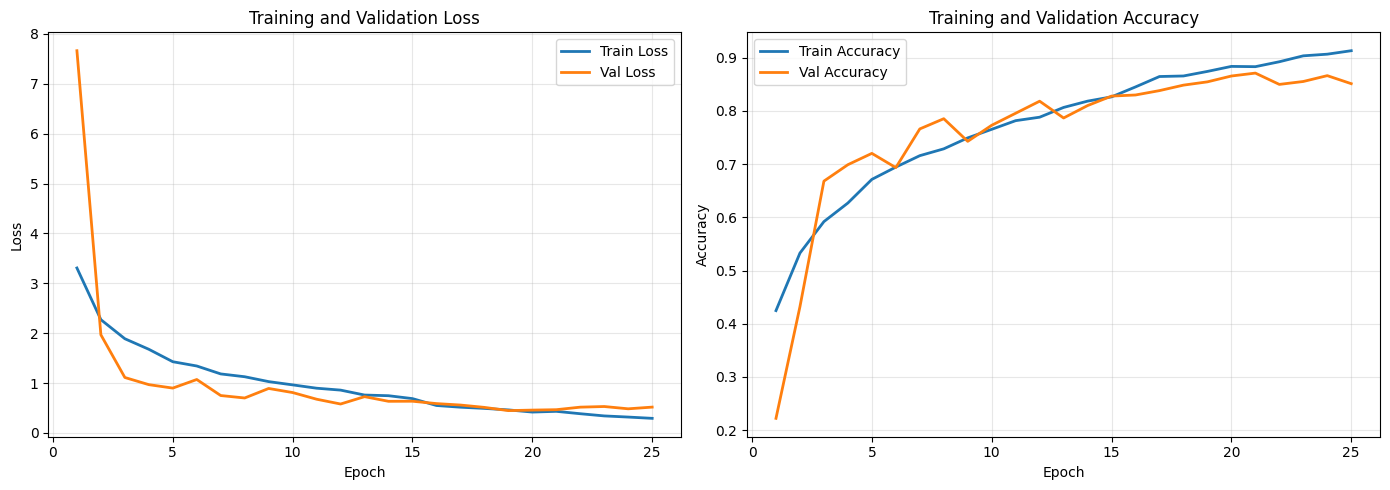

In [ ]:
def plot_training_history(history):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train Loss', linewidth=2)
    plt.plot(epochs, hist['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(epochs, hist['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Blended     0.8521    0.8889    0.8701       324
      Cotton     0.9247    0.9151    0.9199       483
       Denim     0.9638    1.0000    0.9815       133
       Nylon     0.7544    0.8600    0.8037        50
   Polyester     0.8294    0.8545    0.8418       165
        Silk     0.5915    1.0000    0.7434        42
        Wool     0.7544    0.7288    0.7414        59
       other     0.9262    0.6832    0.7863       202

    accuracy                         0.8711      1458
   macro avg     0.8246    0.8663    0.8360      1458
weighted avg     0.8792    0.8711    0.8708      1458



<Figure size 1000x800 with 0 Axes>

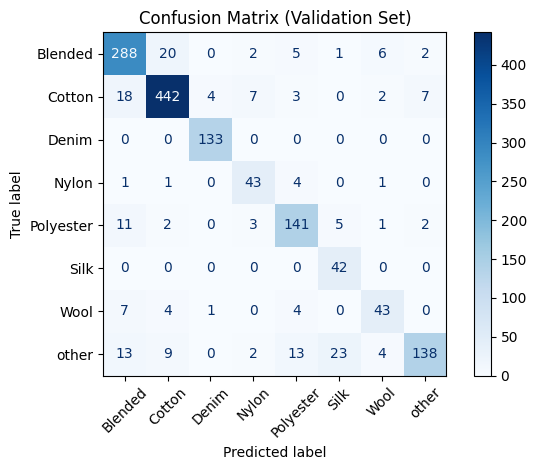

In [ ]:
model = tf.keras.models.load_model("best_fabric_model.keras")

y_true = []
y_pred = []

for x, y in val_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()